### Youtube Video Summarizer

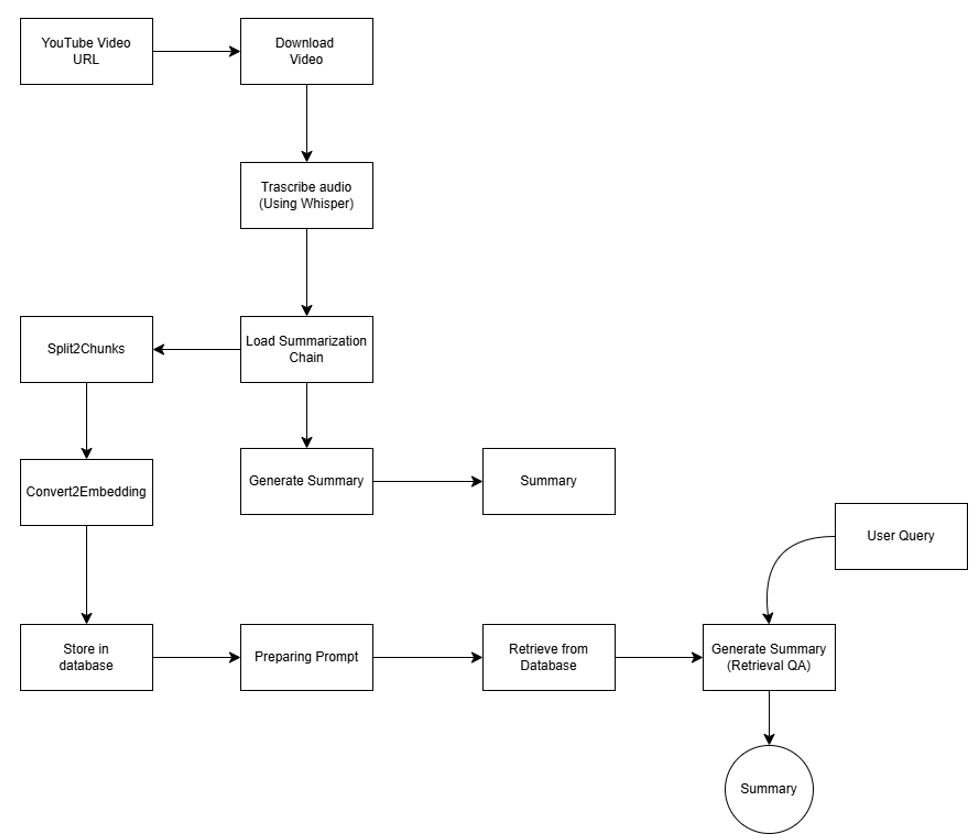

In [1]:
from IPython.display import Image
Image(filename='youtube_summarizer.JPG',width=800, height=400)

In [2]:
# !pip install yt_dlp
# !pip install git+https://github.com/openai/whisper.git

In [2]:
from langchain_openai.embeddings.base import OpenAIEmbeddings
from langchain_text_splitters.character import CharacterTextSplitter
#from langchain_openai import OpenAI
from langchain_openai import ChatOpenAI
#from langchain_community.llms import OpenAI
from langchain_community.document_loaders.url_selenium import SeleniumURLLoader
from langchain_core.prompts.prompt import PromptTemplate
from langchain_core.messages import HumanMessage
import os

In [3]:
ChatOpenAI.api_key=os.getenv("OPENAI_API_KEY2")

In [5]:
# Download

import yt_dlp

def download_mp4_from_youtube(url):
    # Set the options for the download
    filename = 'lecuninterview.mp4'
    ydl_opts = {
        'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]',
        'outtmpl': filename,
        'quiet': True,
    }

    # Download the video file
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        result = ydl.extract_info(url, download=True)

url = "https://www.youtube.com/watch?v=mBjPyte2ZZo"
download_mp4_from_youtube(url)

Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above
         player = https://www.youtube.com/s/player/03dbdfab/player_ias.vflset/en_US/base.js
         n = FDzI6NwmRgOU-pFxv ; player = https://www.youtube.com/s/player/03dbdfab/player_ias.vflset/en_US/base.js
         player = https://www.youtube.com/s/player/03dbdfab/player_ias.vflset/en_US/base.js
         n = JIFAzHetoezpMo_lN ; player = https://www.youtube.com/s/player/03dbdfab/player_ias.vflset/en_US/base.js


In [6]:
# Transcribe
import whisper

model = whisper.load_model("base")
result = model.transcribe("lecuninterview.mp4")
print(result['text'])

100%|███████████████████████████████████████| 139M/139M [00:07<00:00, 19.8MiB/s]
C:\Users\prave\Desktop\HobbyProject\customer_app\lib\site-packages\whisper\__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any i

 Hi, I'm Craig Smith and this is I on A On. This week I talked to Jan LeCoon, one of the seminal figures in deep learning development and a long time proponent of self-supervised learning. Jan spoke about what's missing in large language models and about his new joint embedding predictive architecture which may be a step toward filling that gap. He also talked about his theory of consciousness and the potential for AI systems to someday exhibit the features of consciousness. It's a fascinating conversation that I hope you'll enjoy. Okay, so Jan, it's great to see you again. I wanted to talk to you about where you've gone with so supervised learning since last week spoke. In particular, I'm interested in how it relates to large language models because the large language models really came on stream since we spoke. In fact, in your talk about JEPA, which is joint embedding predictive architecture. There you go. Thank you. You mentioned that large language models lack a world model. I wan

In [7]:
# Save
with open ('text.txt', 'w') as file:  
    file.write(result['text'])

In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts.prompt import PromptTemplate
from langchain.chains.summarize.chain import load_summarize_chain

In [13]:
!pip show langchain

Name: langchain
Version: 0.2.16
Summary: Building applications with LLMs through composability
Home-page: https://github.com/langchain-ai/langchain
Author: 
Author-email: 
License: MIT
Location: c:\users\prave\desktop\hobbyproject\customer_app\lib\site-packages
Requires: aiohttp, async-timeout, langchain-core, langchain-text-splitters, langsmith, numpy, pydantic, PyYAML, requests, SQLAlchemy, tenacity
Required-by: langchain-community


In [5]:
llm = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0)

In [6]:
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=0, separators=[" ", ",", "\n"]
)

In [7]:
from langchain.docstore.document import Document

with open('text.txt') as f:
    text = f.read()

texts = text_splitter.split_text(text)
docs = [Document(page_content=t) for t in texts[:4]]

In [8]:
from langchain.chains.summarize.chain import load_summarize_chain
import textwrap

chain = load_summarize_chain(llm, chain_type="map_reduce")

output_summary = chain.run(docs)
wrapped_text = textwrap.fill(output_summary, width=100)
print(wrapped_text)

C:\Users\prave\AppData\Local\Temp\ipykernel_2824\2050618869.py:6: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use invoke instead.
  output_summary = chain.run(docs)


Craig Smith interviews Jan LeCoon, a prominent figure in deep learning development, about self-
supervised learning and his new joint embedding predictive architecture. Jan discusses the
limitations of large language models and his theory of consciousness in AI systems. The conversation
explores the potential for AI to exhibit consciousness. Jan Le Ka, a professor at New York
University and chief AI scientist at Fair, discusses his work in self-supervised learning and the
joint embedding predictive architecture, which has revolutionized natural language processing. The
text also highlights the limitations of generative models in predicting missing information.


In [9]:
print(chain.llm_chain.prompt.template)

Write a concise summary of the following:


"{text}"


CONCISE SUMMARY:


In [10]:
prompt_template = """Write a concise bullet point summary of the following:

{text}

CONSCISE SUMMARY IN BULLET POINTS:"""

BULLET_POINT_PROMPT = PromptTemplate(template=prompt_template,
                        input_variables=["text"])

In [11]:
chain = load_summarize_chain(llm,
                             chain_type="stuff",
                             prompt=BULLET_POINT_PROMPT)

output_summary = chain.run(docs)

wrapped_text = textwrap.fill(output_summary,
                             width=1000,
                             break_long_words=False,
                             replace_whitespace=False)
print(wrapped_text)

- Craig Smith interviews Jan LeCoon, a deep learning expert, on self-supervised learning and large language models
- Jan discusses his joint embedding predictive architecture and its potential to fill gaps in large language models
- Jan talks about the limitations of generative models in large language models and the difficulty in representing uncertain predictions
- Jan is a professor at New York University and the chief AI scientist at Fair, a fundamental AI research lab at Meta, formerly Facebook


In [12]:
chain = load_summarize_chain(llm, chain_type="refine")
output_summary = chain.run(docs)
wrapped_text = textwrap.fill(output_summary, width=100)
print(wrapped_text)

Craig Smith interviews Jan LeCoon, a prominent figure in deep learning development, about self-
supervised learning and his new joint embedding predictive architecture. Jan LeCoon, a professor at
New York University and the chief AI scientist at Fair, a fundamental AI research lab affiliated
with Meta, formerly known as Facebook, discusses how self-supervised learning has revolutionized
natural language processing through pre-training transformer architectures. In the pre-training
phase, a large neural net is trained to predict missing words in a piece of text, leading to the
system learning good representations of text for downstream tasks like translation or content
moderation. This technique is widely used in practical applications such as contact moderation
systems on platforms like Facebook, Google, and YouTube. Jan LeCoon also touches on the limitations
of large language models and the potential for AI systems to exhibit consciousness. The discussion
also delves into the challeng

In [24]:
# Storage 

import yt_dlp

def download_mp4_from_youtube(urls, job_id):
    # This will hold the titles and authors of each downloaded video
    video_info = []

    for i, url in enumerate(urls):
        # Set the options for the download
        file_temp = f'./{job_id}_{i}.mp4'
        ydl_opts = {
            'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]',
            'outtmpl': file_temp,
            'quiet': True,
        }

        # Download the video file
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            result = ydl.extract_info(url, download=True)
            title = result.get('title', "")
            author = result.get('uploader', "")

        # Add the title and author to our list
        video_info.append((file_temp, title, author))

    return video_info
urls=["https://www.youtube.com/watch?v=mBjPyte2ZZo&t=78s",
    "https://www.youtube.com/watch?v=cjs7QKJNVYM",]
vides_details = download_mp4_from_youtube(urls, 1)

Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above
         player = https://www.youtube.com/s/player/03dbdfab/player_ias.vflset/en_US/base.js
         n = gqlTn4pjKTJmz87Rr ; player = https://www.youtube.com/s/player/03dbdfab/player_ias.vflset/en_US/base.js
         player = https://www.youtube.com/s/player/03dbdfab/player_ias.vflset/en_US/base.js
         n = pkAzKNiOAUtW2XBHW ; player = https://www.youtube.com/s/player/03dbdfab/player_ias.vflset/en_US/base.js


Deprecated Feature: Support for Python version 3.8 has been deprecated. Please update to Python 3.9 or above
         player = https://www.youtube.com/s/player/03dbdfab/player_ias.vflset/en_US/base.js
         n = luRRWw4nwDTwwvK_w ; player = https://www.youtube.com/s/player/03dbdfab/player_ias.vflset/en_US/base.js
         player = https://www.youtube.com/s/player/03dbdfab/player_ias.vflset/en_US/base.js
         n = oXFQU9l63hhlvJxgZ ; player = https://www.youtube.com/s/player/03dbdfab/player_ias.vflset/en_US/base.js


In [25]:
import whisper

# load the model
model = whisper.load_model("base")

# iterate through each video and transcribe
results = []
for video in vides_details:
    result = model.transcribe(video[0])
    results.append( result['text'] )
    print(f"Transcription for {video[0]}:\n{result['text']}\n")



C:\Users\prave\Desktop\HobbyProject\customer_app\lib\site-packages\whisper\__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(fp, map_loc

Transcription for ./1_0.mp4:
 Hi, I'm Craig Smith and this is I on A On. This week I talked to Jan LeCoon, one of the seminal figures in deep learning development and a long time proponent of self-supervised learning. Jan spoke about what's missing in large language models and about his new joint embedding predictive architecture which may be a step toward filling that gap. He also talked about his theory of consciousness and the potential for AI systems to someday exhibit the features of consciousness. It's a fascinating conversation that I hope you'll enjoy. Okay, so Jan, it's great to see you again. I wanted to talk to you about where you've gone with so supervised learning since last week spoke. In particular, I'm interested in how it relates to large language models because the large language models really came on stream since we spoke. In fact, in your talk about JEPA, which is joint embedding predictive architecture. There you go. Thank you. You mentioned that large language mod

TypeError: list indices must be integers or slices, not str

In [37]:
with open ('text.txt', 'w') as file:  
    file.write(results[0])

In [13]:
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
)

# Load the texts
with open('text.txt') as f:
    text = f.read()
texts = text_splitter.split_text(text)

# Split the documents
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=0, separators=[" ", ",", "\n"]
    )
texts = text_splitter.split_text(text)

In [14]:
texts

["Hi, I'm Craig Smith and this is I on A On. This week I talked to Jan LeCoon, one of the seminal figures in deep learning development and a long time proponent of self-supervised learning. Jan spoke about what's missing in large language models and about his new joint embedding predictive architecture which may be a step toward filling that gap. He also talked about his theory of consciousness and the potential for AI systems to someday exhibit the features of consciousness. It's a fascinating conversation that I hope you'll enjoy. Okay, so Jan, it's great to see you again. I wanted to talk to you about where you've gone with so supervised learning since last week spoke. In particular, I'm interested in how it relates to large language models because the large language models really came on stream since we spoke. In fact, in your talk about JEPA, which is joint embedding predictive architecture. There you go. Thank you. You mentioned that large language models lack a world model. I",


In [15]:
from langchain.docstore.document import Document

docs = [Document(page_content=t) for t in texts[:4]]

In [17]:
docs

[Document(page_content="Hi, I'm Craig Smith and this is I on A On. This week I talked to Jan LeCoon, one of the seminal figures in deep learning development and a long time proponent of self-supervised learning. Jan spoke about what's missing in large language models and about his new joint embedding predictive architecture which may be a step toward filling that gap. He also talked about his theory of consciousness and the potential for AI systems to someday exhibit the features of consciousness. It's a fascinating conversation that I hope you'll enjoy. Okay, so Jan, it's great to see you again. I wanted to talk to you about where you've gone with so supervised learning since last week spoke. In particular, I'm interested in how it relates to large language models because the large language models really came on stream since we spoke. In fact, in your talk about JEPA, which is joint embedding predictive architecture. There you go. Thank you. You mentioned that large language models la

In [20]:
from langchain_community.vectorstores.faiss import FAISS
import os
os.environ["ALLOW_DANGEROUS_DESERIALIZATION"] = "true"
# Assuming `texts` is a list of chunks
texts_docs = docs

# Generate embeddings
embeddings = OpenAIEmbeddings(model='text-embedding-ada-002')
faiss_index_docs_video = FAISS.from_documents(texts_docs, embeddings)

# Save FAISS index locally
faiss_index_docs_video.save_local("faiss_index_docs_video")



In [21]:

# Load FAISS index locally
new_faiss_index_docs = FAISS.load_local("faiss_index_docs_video", embeddings, allow_dangerous_deserialization=True)

In [22]:
retriever = new_faiss_index_docs.as_retriever()
retriever.search_kwargs['distance_metric'] = 'cos'
retriever.search_kwargs['k'] = 4

In [23]:
retriever

VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x0000017C1C926EE0>, search_kwargs={'distance_metric': 'cos', 'k': 4})

In [24]:
from langchain_core.prompts.prompt import PromptTemplate
prompt_template = """Use the following pieces of transcripts from a video to answer the question in bullet points and summarized. If you don't know the answer, just say that you don't know, don't try to make up an answer.

{context}

Question: {question}
Summarized answer in bullter points:"""
PROMPT = PromptTemplate(
    template=prompt_template, input_variables=["context", "question"]
)

In [25]:
from langchain.chains import RetrievalQA

chain_type_kwargs = {"prompt": PROMPT}
qa = RetrievalQA.from_chain_type(llm=llm,
                                 chain_type="stuff",
                                 retriever=retriever,
                                 chain_type_kwargs=chain_type_kwargs)

print(qa.run("Summarize the mentions of google according to their AI program"))

- Google uses self-supervised learning in their AI programs
- They use large language models for tasks like content moderation
- Large language models lack a world model
- Google is working on joint embedding predictive architecture to address this issue
